# ЛР1
## Сравнение цен домов Ames Housing в двух группах

В этой работе сравнивается `SalePrice` в двух парах групп, которые формируются по медианам двух количественных признаков.

Выбранные признаки:
- `Year Built`
- `Garage Area`

Признак `Gr Liv Area` не используется, потому что он уже дан в задании как пример, а `SalePrice` нельзя брать как группирующую переменную.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_test
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

AH = pd.read_csv('Ames_dataset/AmesHousing.txt', sep='	')
AH.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### Признаки
По условию группы надо строить по числовым признакам из `AH.describe(include=[np.number])`.

Из этого списка исключим:
- `SalePrice`, потому что это целевая переменная;
- `Gr Liv Area`, потому что она уже приведена в задании как пример;
- `Order` и `PID`, потому что это технические идентификаторы, а не содержательные характеристики дома.

In [2]:
numeric_cols = AH.describe(include=[np.number]).columns.tolist()
usable_numeric_cols = [col for col in numeric_cols if col not in ['SalePrice', 'Gr Liv Area', 'Order', 'PID']]

print(f'Размер таблицы: {AH.shape[0]} строк и {AH.shape[1]} столбцов')
print(f'Всего числовых признаков: {len(numeric_cols)}')
print('Подходящие количественные признаки для группировки:')
usable_numeric_cols

Размер таблицы: 2930 строк и 82 столбцов
Всего числовых признаков: 39
Подходящие количественные признаки для группировки:


['MS SubClass',
 'Lot Frontage',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold']

### выыбор гипотезы

ЧТО ВЫБРАТЬ?

Здесь разумнее проверять именно **равенство медиан**, потому что распределение `SalePrice` заметно асимметрично, а boxplot показывает наличие выбросов. В такой ситуации медиана устойчивее среднего и лучше описывает типичный уровень цен.

Для каждой выбранной переменной будем проверять гипотезы:
- `H0`: медианы `SalePrice` в двух группах равны;
- `H1`: медианы `SalePrice` в двух группах различаются.

Уровень значимости: `alpha = 0.05`.

,Значение
Среднее,180796.06
Медиана,160000.00
Стандартное отклонение,79886.69
Коэффициент асимметрии,1.74


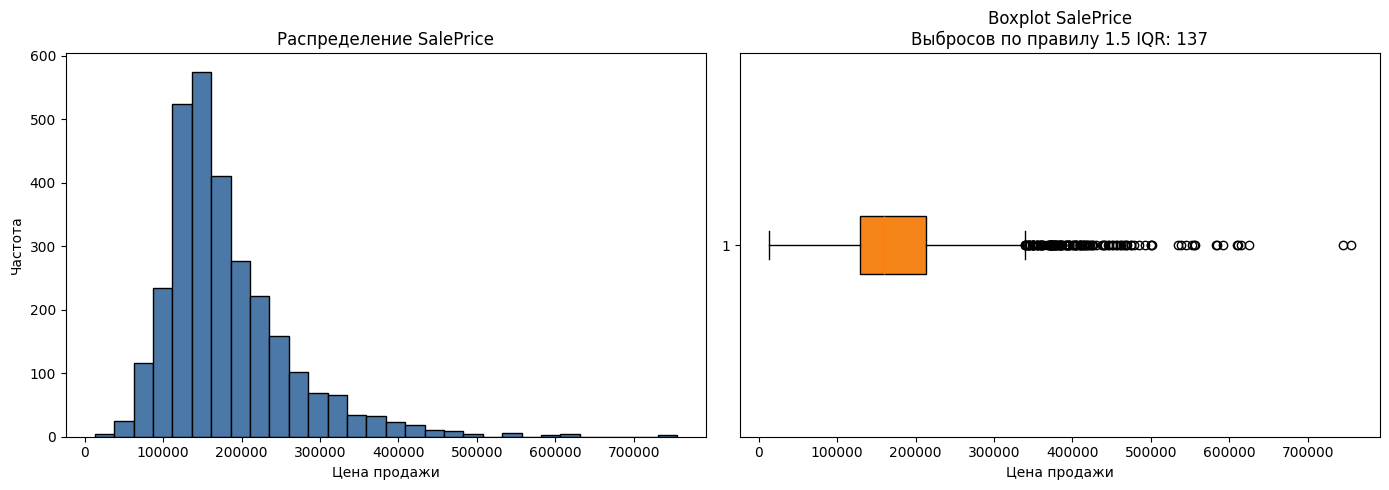

In [10]:
# Оценим форму распределения целевой переменной.
saleprice_stats = pd.Series({
    'Среднее': AH['SalePrice'].mean(),
    'Медиана': AH['SalePrice'].median(),
    'Стандартное отклонение': AH['SalePrice'].std(),
    'Коэффициент асимметрии': AH['SalePrice'].skew()
}).round(2)

# Посчитаем число выбросов по правилу 1.5 IQR.
q1 = AH['SalePrice'].quantile(0.25)
q3 = AH['SalePrice'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_count = ((AH['SalePrice'] < lower_bound) | (AH['SalePrice'] > upper_bound)).sum()

display(saleprice_stats.to_frame('Значение'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(AH['SalePrice'], bins=30, color='#4C78A8', edgecolor='black')
axes[0].set_title('Распределение SalePrice')
axes[0].set_xlabel('Цена продажи')
axes[0].set_ylabel('Частота')

axes[1].boxplot(
    AH['SalePrice'].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#F58518')
)
axes[1].set_title(f'Boxplot SalePrice\nВыбросов по правилу 1.5 IQR: {outliers_count}')
axes[1].set_xlabel('Цена продажи')

plt.tight_layout()
plt.show()


По формулировке задания группы задаются строгими условиями:
- первая группа: значение признака больше медианы;
- вторая группа: значение признака меньше медианы.

Наблюдения, где значение признака точно равно медиане, исключаются из сравнения.

In [ ]:
ALPHA = 0.05 

def analyze_feature(df, feature):
    median_value = df[feature].median()

    #  сравниваем только группы строго ниже и строго выше медианы.
    low_group = df.loc[df[feature] < median_value, 'SalePrice'].dropna()
    high_group = df.loc[df[feature] > median_value, 'SalePrice'].dropna()

    # поверяем гипотезу о равенстве медиан.
    stat, p_value, pooled_median, table = median_test(low_group, high_group)

    summary = pd.DataFrame({
        'Группа': [f'{feature} < медианы', f'{feature} > медианы'],
        'Число наблюдений': [len(low_group), len(high_group)],
        'Медиана SalePrice': [low_group.median(), high_group.median()],
        'Среднее SalePrice': [low_group.mean(), high_group.mean()]
    }).round(2)

    print(f'Признак: {feature}')
    print(f'Медиана признака: {median_value}')
    print(f'Общая медиана SalePrice для критерия: {pooled_median}')
    print(f'Статистика критерия: {stat:.3f}')
    print(f'p-value: {p_value}')
    print('Таблица сопряжённости для median_test:')
    print(table)
    print()

    display(summary)

    plot_df = pd.DataFrame({
        'Группа': [f'{feature} < медианы'] * len(low_group) + [f'{feature} > медианы'] * len(high_group),
        'SalePrice': pd.concat([low_group, high_group], ignore_index=True)
    })

    ax = plot_df.boxplot(column='SalePrice', by='Группа', grid=False, figsize=(10, 6))
    plt.suptitle('')
    ax.set_title(f'Сравнение SalePrice по признаку {feature}')
    ax.set_xlabel('Группа')
    ax.set_ylabel('Цена продажи')
    plt.show()

    if p_value < ALPHA:
        conclusion = 'Отвергаем H0: медианы SalePrice в группах различаются.'
    else:
        conclusion = 'Нет оснований отвергать H0: статистически значимых различий медиан не найдено.'

    print(conclusion)
    print('=' * 90)

    return {
        'Признак': feature,
        'Медиана признака': median_value,
        'Размер группы < медианы': len(low_group),
        'Размер группы > медианы': len(high_group),
        'Медиана SalePrice (<)': low_group.median(),
        'Медиана SalePrice (>)': high_group.median(),
        'Статистика': stat,
        'p-value': p_value,
        'Вывод': conclusion
    }

### 1ая проверка: `Year Built`

Выбираю `Year Built`, потому что это содержательный количественный признак: он естественно разделяет дома на более старые и более новые.

Признак: Year Built
Медиана признака: 1973.0
Общая медиана SalePrice для критерия: 161000.0
Статистика критерия: 1075.832
p-value: 5.911e-236
Таблица сопряжённости для median_test:
[[ 279 1169]
 [1171  290]]



,Группа,Число наблюдений,Медиана SalePrice,Среднее SalePrice
0,Year Built < медианы,1450,132125.0,137067.60
1,Year Built > медианы,1459,204000.0,225025.38


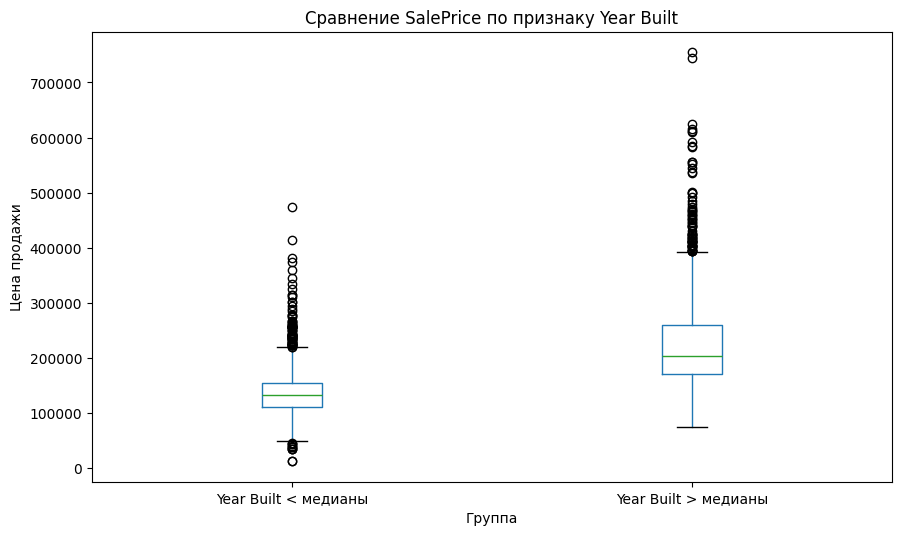

Отвергаем H0: медианы SalePrice в группах различаются.


In [5]:
result_year = analyze_feature(AH, 'Year Built')

### 2ая проверка: `Garage Area`

Выбираю `Garage Area`, потому что это количественная характеристика дома, связанная с его размером и удобством использования.

Признак: Garage Area
Медиана признака: 480.0
Общая медиана SalePrice для критерия: 161000.0
Статистика критерия: 577.911
p-value: 1.068e-127
Таблица сопряжённости для median_test:
[[ 404 1028]
 [1055  388]]



,Группа,Число наблюдений,Медиана SalePrice,Среднее SalePrice
0,Garage Area < медианы,1459,136500.0,141345.96
1,Garage Area > медианы,1416,206000.0,222453.07


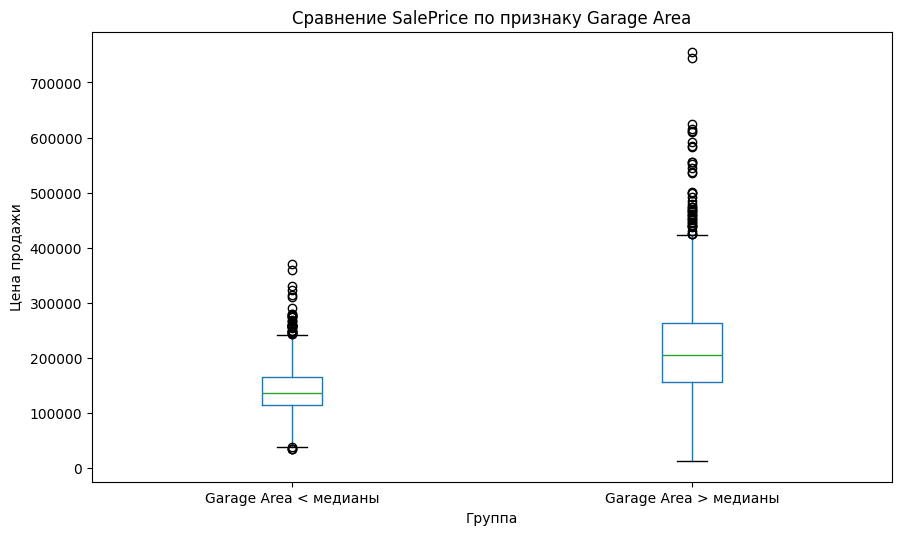

Отвергаем H0: медианы SalePrice в группах различаются.


In [6]:
result_garage = analyze_feature(AH, 'Garage Area')

### Шаг 7. Сведём результаты в одну таблицу

In [8]:
results_df = pd.DataFrame([result_year, result_garage])
results_df[
    [
        'Признак',
        'Медиана признака',
        'Размер группы < медианы',
        'Размер группы > медианы',
        'Медиана SalePrice (<)',
        'Медиана SalePrice (>)',
        'Статистика',
        'p-value'
    ]
].round(3)

,Признак,Медиана признака,Размер группы < медианы,Размер группы > медианы,Медиана SalePrice (<),Медиана SalePrice (>),Статистика,p-value
0,Year Built,1973.0,1450,1459,132125.0,204000.0,1075.832,0.0
1,Garage Area,480.0,1459,1416,136500.0,206000.0,577.911,0.0


### Вывод

Для признаков получились мизерные значения p-value.

В обоих случаях `p-value` намного меньше `0.05`, поэтому нулевая гипотеза о равенстве медиан отвергается.

ТО ЕСТЬ 
- медианная цена продажи статистически значимо различается у более старых и более новых домов;
- медианная цена продажи статистически значимо различается у домов с меньшей и большей площадью гаража.

По данным набора Ames Housing более новые дома и дома с большей площадью гаража имеют существенно более высокую медианную цену продажи.